In [182]:
import numpy as np
import torch.nn as nn
from tqdm import tqdm
from torch.distributions.multivariate_normal import MultivariateNormal
from scipy.optimize import linear_sum_assignment
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/dani/projects/mixture


In [183]:
# B = 16 # Batch size
T = 20 # Number of timesteps
# F = 12 # Numbers of features
K = 4 # Number of mixture components
r = 128 # Estimate the covariance matrix
R = 128 # Number of eigenvalues
r = 4 # Number of eigenvalues in the mean approximation
dt = 1/(T-1)
ts = torch.linspace(0, 1, T)
#X = torch.randn((B, T)) #torch.randn((B, T, F))

lr = 0.1
lambd_reg = 0

sigma = 5 # Functional RBF
alpha=-1/(2*sigma**2)

sigmas = np.array([1, 0.3, 2, 0.1]) # Mixture model data
assert len(sigmas)==K

In [184]:
def rbf_fkernel(x1, x2, dt, alpha=-1.0): # (B, T, F) or (B, T)
    y = dt*torch.square(x1-x2) #.sum(-1) # (B, B, T)
    norm = (y[..., 0] / 2 + y[..., 1:-1].sum(dim=-1) + y[..., -1] / 2) # (B, B)
    return torch.exp(alpha*norm)

def rbf_kernel(x1, x2, sigma): # (B, F) or (B)
    norm = torch.square(x1-x2) #.sum(-1) # (B, B)
    return torch.exp(-1/(2*sigma**2)*norm)

In [185]:
t1, t2 = ts[:, None], ts[None, :]

num = np.array([50, 100, 40, 50]) # Num samples for dataset
means = [5*torch.sin(2*ts), torch.zeros(T), 10*torch.cos(4*ts), -10*torch.cos(4*ts)]
X1 = MultivariateNormal(means[0], 1*rbf_kernel(t1, t2, sigma=1) + 1e-5 * torch.eye(T)).sample((num[0],))
X2 = MultivariateNormal(means[1], rbf_kernel(t1, t2, sigma=0.3) + 1e-5 * torch.eye(T)).sample((num[1],))
X3 = MultivariateNormal(means[2], 1*rbf_kernel(t1, t2, sigma=2) + 1e-5 * torch.eye(T)).sample((num[2],))
X4 = MultivariateNormal(means[3], 1*rbf_kernel(t1, t2, sigma=0.1) + 1e-5 * torch.eye(T)).sample((num[3],))
Xs = [X1, X2, X3, X4]
X = torch.concatenate(Xs, dim=0)

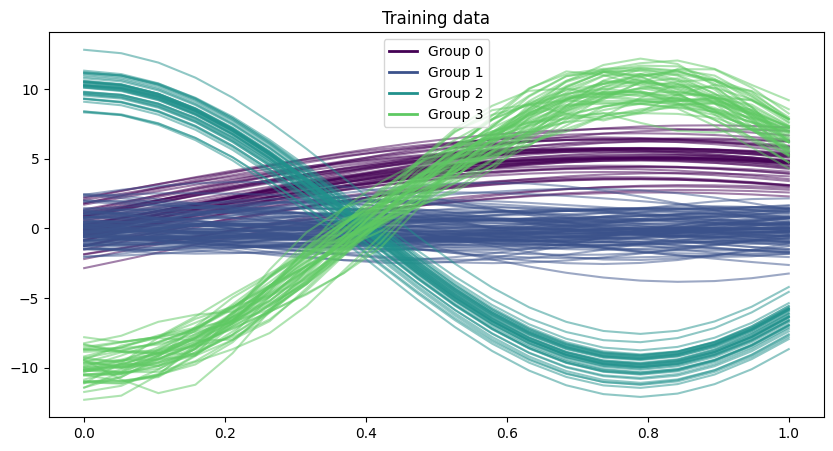

In [186]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax.legend(handles=legend_elements)
ax.set_title("Training data")
plt.show()

In [187]:
mean_func = X.mean(axis=0)
X_centered = X #X - mean_func
C = X_centered.T.cov()
# Eigen-decomposition
m_eigvals, m_eigvecs = torch.linalg.eigh(C)

# Sort descending by variance
idx = torch.argsort(m_eigvals, descending=True)
m_eigvals = m_eigvals[idx]
m_eigvecs = m_eigvecs[:, idx]
scores = X_centered @ m_eigvecs

#k = 3  # number of components
X_recon = scores[:, :r] @ m_eigvecs[:, :r].T #+ mean_func

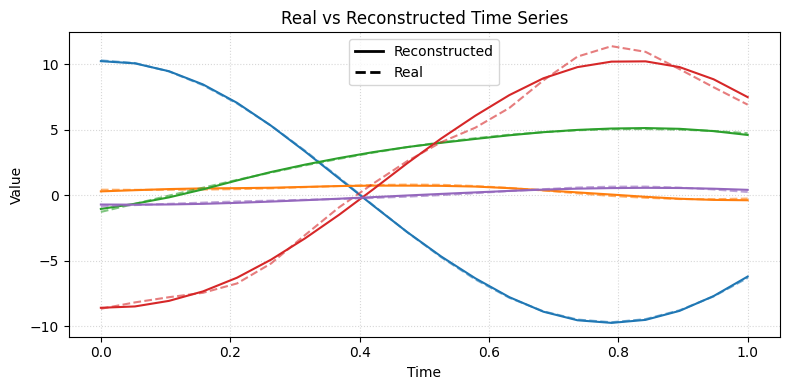

In [188]:
cmap = mpl.colormaps['tab10']

plt.figure(figsize=(8, 4))
rand_ind = np.random.choice(X.shape[0], size=5, replace=False)
for i, idx in enumerate(rand_ind):
    color = cmap(i)
    plt.plot(ts, X_recon[idx], color=color)
    plt.plot(ts, X[idx], '--', color=color, alpha=0.6,)

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Real vs Reconstructed Time Series')
legend_elements = [
    Line2D([0], [0], color='k', lw=2, label='Reconstructed'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Real')
]
plt.legend(handles=legend_elements, loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [189]:
""" X: [B, T]
    m: [K, T]
    evals: [K, R]
    evecs: [K, T, R]
    K_math: [K, T, T]
"""

def get_J(X, m, evals, evecs, alpha):
    p1 = 1/torch.sqrt(torch.prod(1 - 2*alpha*evals, dim=-1)) # [K]
    a1 = X[:, None, :] - m[None, :, :] # [B, K, T]
    b1 = torch.square(torch.sum(a1[..., None] * evecs[None], dim=2)) * dt # [B, K, R] # TODO
    c1 = b1 / (1-2*alpha*evals[None]) # [B, K, R]
    d1 = p1*torch.exp(alpha*torch.sum(c1, dim=-1))
    return torch.mean(d1, dim=0)


def get_I(X, m, evals, evecs, alpha):
    p2 = 1/torch.sqrt(torch.prod(1 - 2*alpha*(evals[None, :, :] + evals[:, None, :]),dim=-1))
    a2 = (m[None, :, :] - m[:, None, :])
    b2 = (evecs[None, :] + evecs[:, None])/2
    c2 = torch.square(torch.sum(a2[..., None] * b2, dim=2)) * dt # TODO
    d2 = c2 / (1-2*alpha*(evals[None, :]+evals[:, None]))
    return p2*torch.exp(alpha*torch.sum(d2, dim=-1))


def MMD(X, I, J, pi):
    E1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
    E2 = torch.dot(pi,J)
    E3 = torch.dot(pi,I @ pi)
    return E1, E2, E3

In [190]:
kernels = [lambda x1, x2, s=s: rbf_kernel(x1, x2, sigma=s) for s in sigmas]
K_mat = torch.stack([kernel(t1, t2) for kernel in kernels]) * dt # [2 x 100 x 100]

evals, evecs = torch.linalg.eigh(K_mat)
# eigh returns eigenvalues in ascending order, so take the last R
evals, evecs = evals[..., -R:], evecs[..., -R:]
evals, evecs = torch.flip(evals, dims=[-1]), torch.flip(evecs, dims=[-1])

## 1.1 Train using gradient descent

In [195]:
m_scores = nn.Parameter(torch.randn((K,r)))
pi_logits = nn.Parameter(torch.randn((K,)))

m = m_scores @ m_eigvecs[:, :r].T  # [K, T]
J = get_J(X, m, evals, evecs, alpha)
I = get_I(X, m, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J, pi_logits)
MMD(X, I, J, pi_logits)

(tensor(0.5488),
 tensor(-1.1123, grad_fn=<DotBackward0>),
 tensor(2.7931, grad_fn=<DotBackward0>))

In [196]:
optimizer = torch.optim.Adam([m_scores, pi_logits], lr=lr)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    m = m_scores @ m_eigvecs[:, :r].T  # [K, T]
    J = get_J(X, m, evals, evecs, alpha)
    I = get_I(X, m, evals, evecs, alpha)
    pi = torch.softmax(pi_logits, dim=0)
    E1, E2, E3 = MMD(X, I, J, pi)
    loss_reg = m_scores.square().mean(0).mean()#torch.sum(m.square(), axis=0).sum()*dt
    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: 0.0156, E1: 0.5488, E2: 0.5358, E3: 0.5386, loss_reg: 163.2274: 100%|██████████| 1000/1000 [00:07<00:00, 131.07it/s]


In [197]:
cost_matrix = torch.zeros((K, K))
for i in range(K):
    for j in range(K):
        cost_matrix[i, j] = torch.mean((means[i] - m[j])**2).item()

row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())
for true_idx, learned_idx in zip(row_ind, col_ind):
    mse = cost_matrix[true_idx, learned_idx].item()

In [198]:
estimated_pi = torch.softmax(pi, dim=0).detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.22946702 0.30106592 0.22768506 0.24178204]
True pi:  [0.20833333 0.41666667 0.16666667 0.20833333]


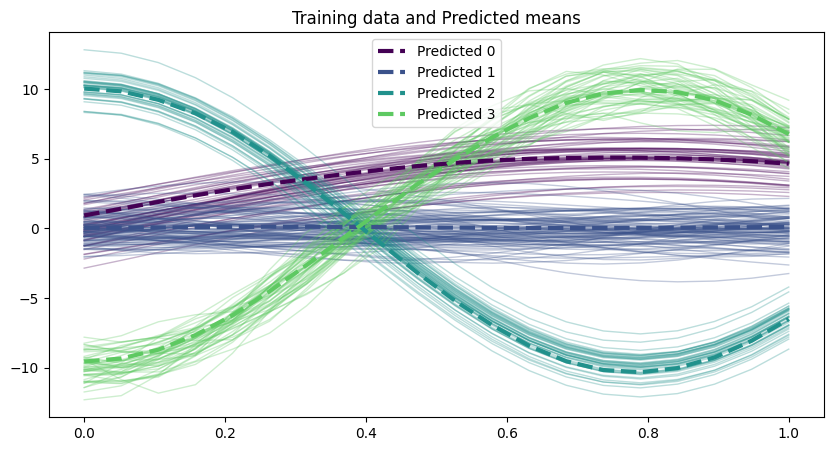

In [199]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')

# Plot training data
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.3, color=cmap(i/len(Xs)), linewidth=1)

# Plot predicted means
for i in range(K):
    ax.plot(ts, m[col_ind[i]].detach().numpy(), color=cmap(i/K), lw=3, label=f'Predicted {i}', linestyle='--')

ax.legend()
ax.set_title("Training data and Predicted means")
plt.show()

Estimated pi (reordered): [0.22946702 0.30106592 0.22768506 0.24178204]
True pi:                  [0.20833333 0.41666667 0.16666667 0.20833333]
Aboslute Error:           [0.02113369 0.11560074 0.0610184  0.03344871]
Mean Absolute Error:           0.057800


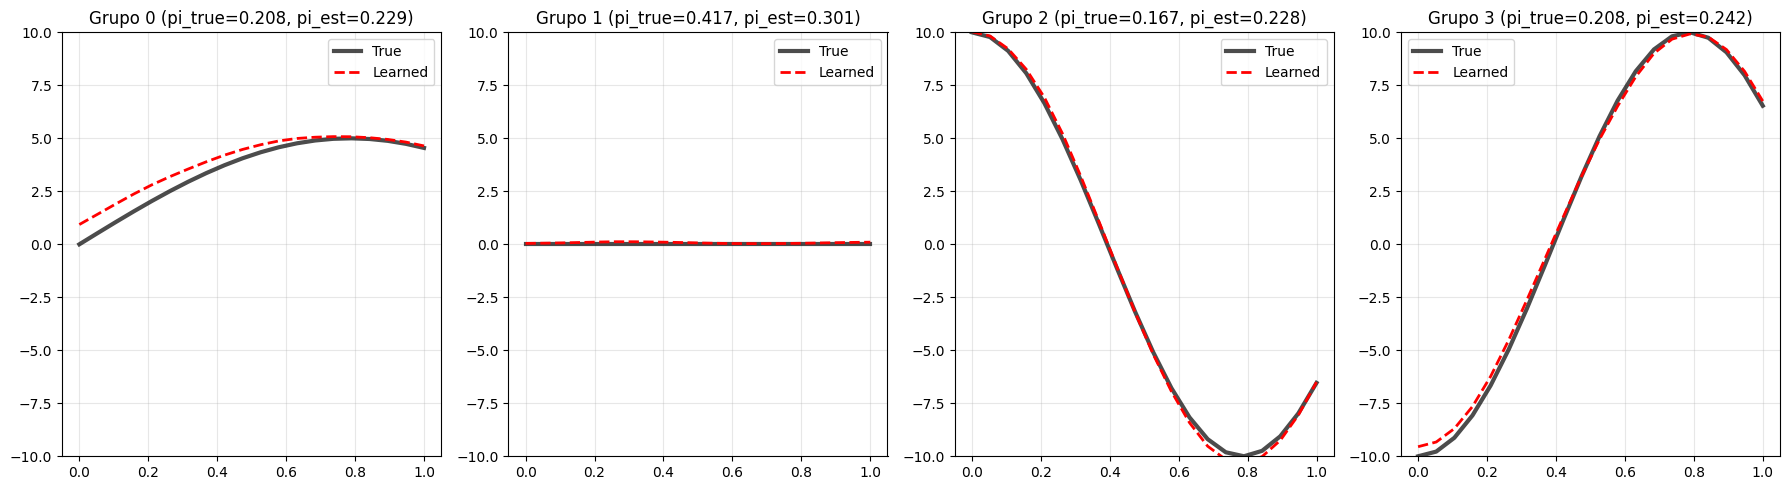

In [200]:
# 3. Compara pi
reordered_pi = estimated_pi[col_ind]
true_pi = num/np.sum(num)

print(f"Estimated pi (reordered): {reordered_pi}")
print(f"True pi:                  {true_pi}")
print(f"Aboslute Error:           {np.abs(reordered_pi - true_pi)}")
print(f"Mean Absolute Error:           {np.mean(np.abs(reordered_pi - true_pi)):.6f}")

# 4. Visualiza
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i in range(K):
    axes[i].plot(ts, means[i].numpy(), 'k-', lw=3, label='True', alpha=0.7)
    learned_idx = col_ind[i]
    axes[i].plot(ts, m[learned_idx].detach().numpy(), 'r--', lw=2, label='Learned')
    axes[i].set_title(f'Grupo {i} (pi_true={true_pi[i]:.3f}, pi_est={reordered_pi[i]:.3f})')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim((-10,10))

plt.tight_layout()
plt.show()

## 1.2 Train $\pi$ using closed formula

In [201]:
m_scores = nn.Parameter(torch.randn((K,r)))
pi = torch.full((K,), 1/K)

In [202]:
optimizer = torch.optim.Adam([m_scores], lr=lr)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    m = m_scores @ m_eigvecs[:, :r].T  # [K, T]
    J = get_J(X, m, evals, evecs, alpha)
    I = get_I(X, m, evals, evecs, alpha)
    E1, E2, E3 = MMD(X, I, J, pi)
    loss_reg = m_scores.square().mean(0).mean()#torch.sum(m.square(), axis=0).sum()*dt

    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    loss.backward()
    optimizer.step()

    if i%10==0:
        with torch.no_grad():
            I_inv = torch.inverse(I)
            Ones = torch.ones_like(pi)
            pi = I_inv @ J - ((torch.dot(Ones, I_inv @ J) - 1)/torch.dot(Ones, I_inv @ Ones)) * (I_inv @ Ones)
            pi = torch.clamp(pi, min=0, max=1)
            pi /= 1e-7+torch.sum(pi)
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: 0.0166, E1: 0.5488, E2: 0.5362, E3: 0.5403, loss_reg: 174.2641: 100%|██████████| 1000/1000 [00:05<00:00, 176.14it/s]


In [203]:
cost_matrix = torch.zeros((K, K))
for i in range(K):
    for j in range(K):
        cost_matrix[i, j] = torch.mean((means[i] - m[j])**2).item()

row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())
for true_idx, learned_idx in zip(row_ind, col_ind):
    mse = cost_matrix[true_idx, learned_idx].item()

In [204]:
estimated_pi = torch.softmax(pi, dim=0).detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.24629831 0.29478243 0.23021267 0.2287066 ]
True pi:  [0.20833333 0.41666667 0.16666667 0.20833333]


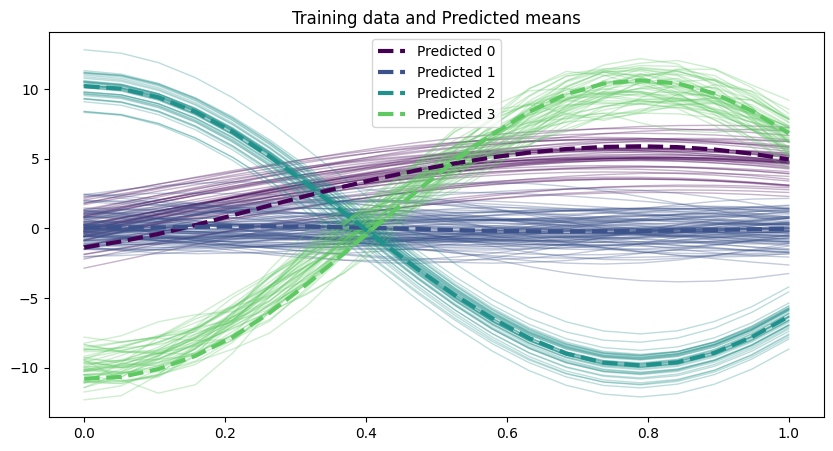

In [205]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')

# Plot training data
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.3, color=cmap(i/len(Xs)), linewidth=1)

# Plot predicted means
for i in range(K):
    ax.plot(ts, m[col_ind[i]].detach().numpy(), color=cmap(i/K), lw=3, label=f'Predicted {i}', linestyle='--')

ax.legend()
ax.set_title("Training data and Predicted means")
plt.show()

In [212]:
estimated_pi = pi.detach().numpy()
print("Estimated pi: ", estimated_pi[col_ind])
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.2404873  0.4201814  0.17294739 0.1663838 ]
True pi:  [0.20833333 0.41666667 0.16666667 0.20833333]


## Test against Empirical MMD

In [207]:
num_samples = 300
Y = [MultivariateNormal(m[i].detach(), rbf_kernel(t1, t2, sigma=sigmas[i]) + 1e-5*torch.eye(T)).sample((1,)) for i in np.random.choice(4, size=num_samples, p=pi.detach().numpy())]
y = torch.concatenate(Y, dim=0)

In [208]:
e1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], X[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [209]:
J = get_J(X, m, evals, evecs, alpha)
I = get_I(X, m, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J, pi)

Loss = E1 - 2*E2 + E3

In [210]:
print(f"Empirical Total loss:\t\t {loss.item():2.4f}\tE1: {e1.item():7.4f}, E2: {e2.item():7.4f}, E3: {e3.item():7.4f}")
print(f"Approximation Total loss:\t {Loss.item():2.4f}\tE1: {E1.item():7.4f}, E2: {E2.item():7.4f}, E3: {E3.item():7.4f}")

Empirical Total loss:		 0.0017	E1:  0.5488, E2:  0.5401, E3:  0.5332
Approximation Total loss:	 0.0166	E1:  0.5488, E2:  0.5362, E3:  0.5403


## Test that Empirical MMD is the same as Calculated

In [191]:
pi = torch.tensor(num/num.sum()).type(torch.float32)
means = torch.tensor(np.array(means, dtype=np.float32))

num_samples = 800
Y = [MultivariateNormal(means[i].detach(), rbf_kernel(t1, t2, sigma=sigmas[i]) + 1e-5*torch.eye(T)).sample((1,)) for i in np.random.choice(len(pi), size=num_samples, p=pi.detach().numpy())]
y = torch.concatenate(Y, dim=0)

In [192]:
e1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], X[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [193]:
J = get_J(X, means, evals, evecs, alpha)
I = get_I(X, means, evals, evecs, alpha)
E1, E2, E3 = MMD(X, I, J, pi)

Loss = E1 - 2*E2 + E3

In [194]:
print(f"Empirical Total loss:\t\t {loss.item():2.4f}\tE1: {e1.item():7.4f}, E2: {e2.item():7.4f}, E3: {e3.item():7.4f}")
print(f"Approximation Total loss:\t {Loss.item():2.4f}\tE1: {E1.item():7.4f}, E2: {E2.item():7.4f}, E3: {E3.item():7.4f}")

Empirical Total loss:		 0.0006	E1:  0.5488, E2:  0.5461, E3:  0.5440
Approximation Total loss:	 0.0165	E1:  0.5488, E2:  0.5381, E3:  0.5441
